In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import torch
from torch.utils.data import DataLoader

from dataset import SceneTwoPairsDataset
from model import PairImageCylinderModel
from losses import supervised_loss

from debugger import bug_check


In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA available: True
NVIDIA GeForce RTX 5050 Laptop GPU


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = PairImageCylinderModel(
    img_size=128,
    patch_size=16,
    in_chans=3,
    embed_dim=256,
    depth=4,
    num_heads=4,
    num_bins=32,
    dropout=0.1,
).to(device)

In [5]:
dataset = SceneTwoPairsDataset(
    root_dir="dataset",
    image_size=128,
    debugg=False,
)

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
)


In [6]:
# bug_check(0)

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

model.train()
for epoch in range(10):
    total = 0.0
    total_vis = 0.0
    total_radius = 0-0
    total_depth = 0.0
    total_pose = 0.0
    total_t = 0.0
    total_r = 0.0

    for batch in loader:
        img_a, vision_a, img_b, pose_ab = batch

        img_a = img_a.to(device, non_blocking=True)
        img_b = img_b.to(device, non_blocking=True)
        vision_a = vision_a.to(device, non_blocking=True)
        pose_ab = pose_ab.to(device, non_blocking=True)

        pred_vision, pred_pose = model(img_a, img_b)

        loss_out = supervised_loss(
            pred_vision,
            vision_a,
            pred_pose,
            pose_ab,
            lambda_pose=1.0,
            lambda_vis_a=1.0,
            occ_thresh=0.5,
            lambda_occ=1.0,
            lambda_radius=10.0,
            lambda_depth=1.0,
            t_weight=1.0,
            r_weight=1.0,
        )

        loss = loss_out["total"]

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        total += loss.item()
        total_vis += loss_out["vision_a"].item()
        total_radius += loss_out["vision_a_radius"].item()
        total_pose += loss_out["pose"].item()
        total_depth += loss_out["vision_a_depth"].item()
        total_t += loss_out["translation"].item()
        total_r += loss_out["rotation"].item()

    n = len(loader)

    print(
        f"Epoch {epoch+1}: "
        f"total={total/n:.4f} | "
        f"vision={total_vis/n:.4f} | "
        f"radius={total_radius/n:.4f} | "
        f"depth={total_depth/n:.4f} "
        f"pose={total_pose/n:.4f} | "
        f"t={total_t/n:.4f} | "
        f"r={total_r/n:.4f}"
    )

Epoch 1: total=7.3283 | vision=6.8873 | radius=0.1823 | depth=6.0097 pose=0.4410 | t=0.2509 | r=0.1901
Epoch 2: total=6.7293 | vision=6.4157 | radius=0.1640 | depth=5.5629 pose=0.3136 | t=0.2526 | r=0.0610
Epoch 3: total=6.3615 | vision=6.0491 | radius=0.1524 | depth=5.2132 pose=0.3124 | t=0.2509 | r=0.0615
Epoch 4: total=6.1374 | vision=5.8225 | radius=0.1515 | depth=4.9928 pose=0.3149 | t=0.2528 | r=0.0621
Epoch 5: total=5.8556 | vision=5.5517 | radius=0.1456 | depth=4.7349 pose=0.3039 | t=0.2487 | r=0.0552
Epoch 6: total=5.4635 | vision=5.1551 | radius=0.1388 | depth=4.3425 pose=0.3084 | t=0.2478 | r=0.0606
Epoch 7: total=5.1209 | vision=4.8133 | radius=0.1354 | depth=4.0066 pose=0.3076 | t=0.2505 | r=0.0571
Epoch 8: total=4.8754 | vision=4.5675 | radius=0.1373 | depth=3.7589 pose=0.3079 | t=0.2491 | r=0.0588
Epoch 9: total=4.6183 | vision=4.2840 | radius=0.1377 | depth=3.4793 pose=0.3343 | t=0.2470 | r=0.0873
Epoch 10: total=4.6386 | vision=4.3318 | radius=0.1349 | depth=3.5292 pos

In [8]:
# Inference + utskrift + plottar på samma dataset som träningen
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Samma dataset som i träningen, men utan shuffle för stabil visualisering
infer_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
)

def pose_to_text(pose_4):
    """
    pose_4: tensor [tx, ty, sin(yaw), cos(yaw)]
    """
    tx, ty, s, c = pose_4.tolist()
    yaw_deg = np.degrees(np.arctan2(s, c))
    return f"tx={tx:.3f}, ty={ty:.3f}, yaw={yaw_deg:.1f}°"

def show_image_pair(img_a, img_b, title=None):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_a.permute(1, 2, 0).cpu().clamp(0, 1))
    axes[0].set_title("Image A")
    axes[0].axis("off")

    axes[1].imshow(img_b.permute(1, 2, 0).cpu().clamp(0, 1))
    axes[1].set_title("Image B")
    axes[1].axis("off")

    if title is not None:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

model.eval()

batch = next(iter(infer_loader))
img_a, vision_a, img_b, pose_ab = batch

img_a = img_a.to(device)
vision_a = vision_a.to(device)
img_b = img_b.to(device)
pose_ab = pose_ab.to(device)

with torch.no_grad():
    pred_vision, pred_pose = model(img_a, img_b)

# Skriv ut resultat för några samples
n_show = min(4, img_a.shape[0])
for i in range(n_show):
    print(f"Sample {i}")
    print("  GT   pose:", pose_to_text(pose_ab[i].detach().cpu()))
    print("  Pred pose:", pose_to_text(pred_pose[i].detach().cpu()))

    pose_err = torch.abs(pred_pose[i] - pose_ab[i]).detach().cpu()
    print(f"  |err|     : tx={pose_err[0]:.3f}, ty={pose_err[1]:.3f}, sin={pose_err[2]:.3f}, cos={pose_err[3]:.3f}")
    print()

Sample 0
  GT   pose: tx=-0.151, ty=-0.989, yaw=-6.8°
  Pred pose: tx=-0.054, ty=0.103, yaw=0.0°
  |err|     : tx=0.096, ty=1.092, sin=0.118, cos=0.007

Sample 1
  GT   pose: tx=-0.910, ty=-0.415, yaw=-7.9°
  Pred pose: tx=-0.052, ty=0.102, yaw=0.3°
  |err|     : tx=0.858, ty=0.517, sin=0.143, cos=0.010

Sample 2
  GT   pose: tx=0.416, ty=0.909, yaw=-12.7°
  Pred pose: tx=-0.052, ty=0.105, yaw=0.1°
  |err|     : tx=0.468, ty=0.804, sin=0.223, cos=0.025

Sample 3
  GT   pose: tx=-0.520, ty=0.854, yaw=4.8°
  Pred pose: tx=-0.052, ty=0.106, yaw=-0.1°
  |err|     : tx=0.468, ty=0.748, sin=0.085, cos=0.003



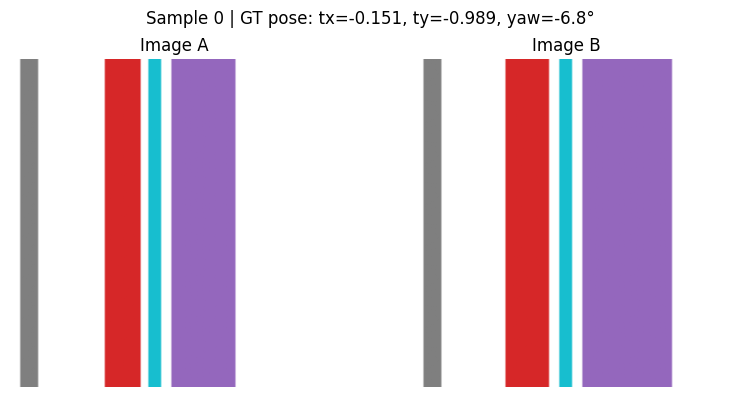

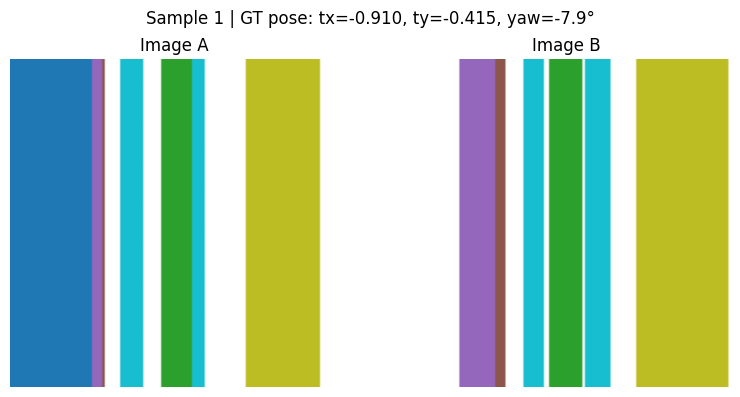

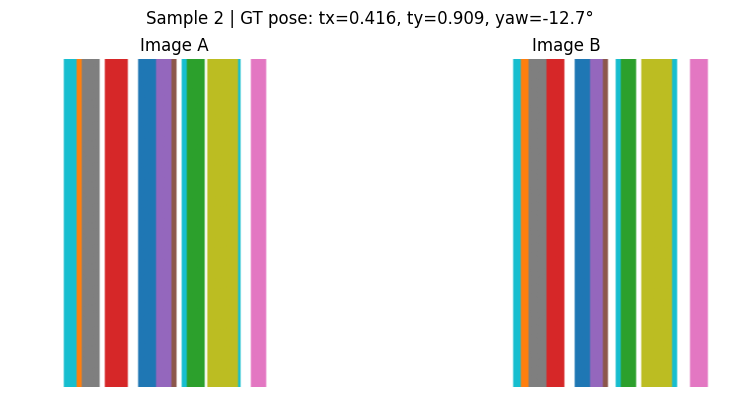

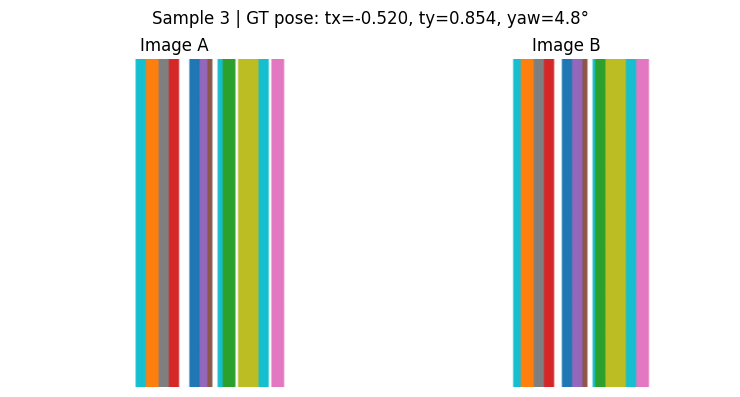

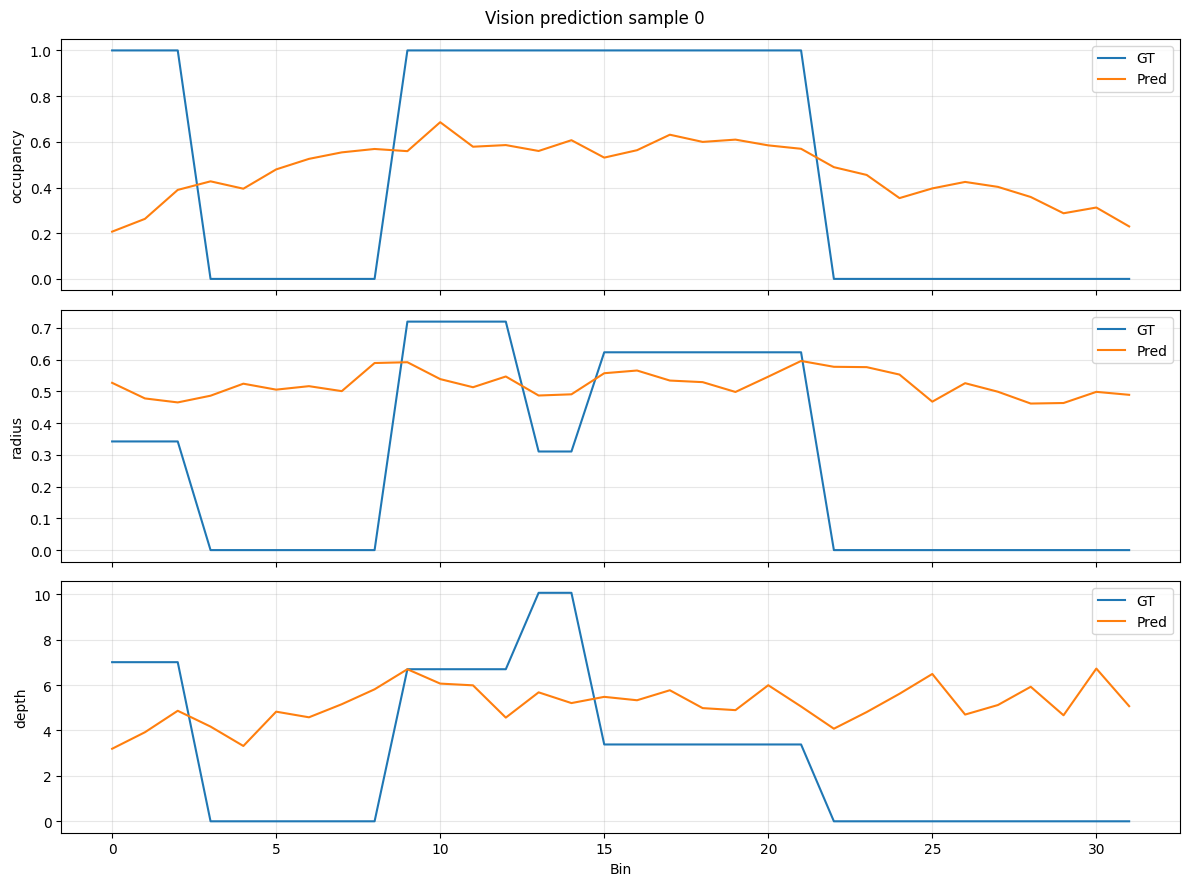

In [9]:
# Plotta bildpar
for i in range(n_show):
    show_image_pair(
        img_a[i].detach().cpu(),
        img_b[i].detach().cpu(),
        title=f"Sample {i} | GT pose: {pose_to_text(pose_ab[i].detach().cpu())}"
    )

# Plotta vision-output för första samplet
sample_idx = 0
bins = np.arange(pred_vision.shape[1])

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

names = ["occupancy", "radius", "depth"]
for j, ax in enumerate(axes):
    gt = vision_a[sample_idx, :, j].detach().cpu().numpy()
    pr = pred_vision[sample_idx, :, j].detach().cpu().numpy()

    ax.plot(bins, gt, label="GT")
    ax.plot(bins, pr, label="Pred")
    ax.set_ylabel(names[j])
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Bin")
fig.suptitle(f"Vision prediction sample {sample_idx}")
plt.tight_layout()
plt.show()